# ANALISA 1 (14-4-2026)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
import re

warnings.filterwarnings('ignore')

# 1. Load File Master untuk Mapping Jenis Alat (Dengan header=1)
df_master = pd.read_excel('cost & bbm 2022 sd 2025 HP & Type.xlsx', sheet_name='Sheet2', header=1)

# Membersihkan kolom nama di master agar pencocokan presisi
df_master['UNIT_MASTER'] = df_master['NAMA ALAT BERAT'].astype(str).str.strip().str.upper()

# Membuat kamus data menggunakan kolom 'ALAT BERAT'
mapping_type = dict(zip(df_master['UNIT_MASTER'], df_master['ALAT BERAT'].astype(str).str.strip().str.upper()))

print(f"Berhasil memuat mapping untuk {len(mapping_type)} unit dari file master.")

Berhasil memuat mapping untuk 245 unit dari file master.


In [7]:
def load_and_melt_excel(file_path):
    all_data = []
    xls = pd.read_excel(file_path, sheet_name=None, header=[0, 1, 2])
    for sheet_name, df in xls.items():
        if df.empty or len(df.columns) == 0:
            continue

        df = df.set_index(df.columns[0]) 
        df.index.name = 'TANGGAL'
        df.columns = df.columns.droplevel(1) 
        df_stacked = df.stack(level=0).reset_index()
        df_stacked.rename(columns={'level_1': 'EQUIP NAME'}, inplace=True)
        all_data.append(df_stacked)
    df_final = pd.concat(all_data, ignore_index=True)
    df_final['TANGGAL'] = pd.to_datetime(df_final['TANGGAL'], format='%d-%m-%Y', errors='coerce')
    df_final = df_final.dropna(subset=['TANGGAL'])
    return df_final

# 1. Load data operasional — Training: 2023-2024 | Test: 2025
df_2023 = load_and_melt_excel('BBM AAB 2023.xlsx')
df_2024 = load_and_melt_excel('BBM AAB 2024 & Des 2025.xlsx')
df_2025 = load_and_melt_excel('BBM AAB Jan-Nov 2025.xlsx')
df_all = pd.concat([df_2023, df_2024, df_2025], ignore_index=True)

# 2. Preprocessing Data Mentah (Delta HM & Anomali)
df_all = df_all.sort_values(by=['EQUIP NAME', 'TANGGAL'])
df_all['HM_Clean'] = pd.to_numeric(df_all['HM'], errors='coerce').replace(0, np.nan)
df_all['HM_Clean'] = df_all.groupby('EQUIP NAME')['HM_Clean'].ffill().fillna(0)
df_all['Delta_HM'] = df_all.groupby('EQUIP NAME')['HM_Clean'].diff().fillna(0)
df_all.loc[df_all['Delta_HM'] < 0, 'Delta_HM'] = 0
df_all.loc[df_all['Delta_HM'] > 100, 'Delta_HM'] = 0 

df_all['LITER_Clean'] = pd.to_numeric(df_all['LITER'], errors='coerce').fillna(0)

# =========================================================================
# 3. TEMBOK FILTER: EXCLUDE ALAT MATI SURI & LITER NOL
# =========================================================================
akumulasi_unit = df_all.groupby('EQUIP NAME').agg({
    'Delta_HM': 'sum',
    'LITER_Clean': 'sum'
})

unit_lulus_filter = akumulasi_unit[
    (akumulasi_unit['Delta_HM'] > 0) & 
    (akumulasi_unit['LITER_Clean'] > 0)
].index

df_all = df_all[df_all['EQUIP NAME'].isin(unit_lulus_filter)].copy()
# =========================================================================

# 4. Aturan Smart Matching (Integrasi File Master)
aturan_manual = {
    "FL RENTAL 01": "FL RENTAL 01 TIMIKA",
    "TOBATI (EX.FL KALMAR 32T)": "TOP LOADER KALMAR 35T/TOBATI",
    "L 8477 UUC (EX.L 9902 UR)": "L 9902 UR / S75",
    "WIND RIVER (EX.TL BOSS 42T)": "TOP LOADER BOSS",
    "L 8658 UK (EX.L 9582 UQ)": "L 9582 UQ"
}

def smart_mapping(raw_name, master_dict):
    raw_name = str(raw_name).strip().upper()
    
    if raw_name in aturan_manual:
        target = aturan_manual[raw_name]
        if target in master_dict: return master_dict[target]
        
    before_paren = raw_name.split('(')[0].strip()
    if before_paren in master_dict: return master_dict[before_paren]
        
    if raw_name in master_dict: return master_dict[raw_name]
        
    if "EX." in raw_name or "EX " in raw_name:
        try:
            after_ex = re.split(r'EX\s*\.?\s*', raw_name)[1].replace(')', '').strip()
            if after_ex in master_dict: return master_dict[after_ex]
        except IndexError:
            pass 
            
    return "TIDAK TERDAFTAR"

df_all['TYPE'] = df_all['EQUIP NAME'].apply(lambda x: smart_mapping(x, mapping_type))
df_all_raw = df_all.copy()

# 5. Filter: Hanya menyertakan armada inti
alat_diizinkan = ['TRAILER', 'TRONTON', 'FORKLIFT', 'CRANE', 'TOP LOADER', 'SIDE LOADER', 'REACH STACKER']
df_all = df_all[df_all['TYPE'].isin(alat_diizinkan)].copy()

# 6. Agregasi Rata-Rata Makro (Metode 2 Tahap yang Benar)
unit_counts = df_all.groupby('TYPE')['EQUIP NAME'].nunique().to_dict()
df_all['TYPE_LABEL'] = df_all['TYPE'].apply(lambda x: f"{x} (n={unit_counts.get(x, 0)})")
df_all['TAHUN_BULAN'] = df_all['TANGGAL'].dt.to_period('M').astype(str)

# Tahap 1: Kumulasi per unit
df_unit_monthly = df_all.groupby(['TYPE_LABEL', 'TYPE', 'EQUIP NAME', 'TAHUN_BULAN'])['Delta_HM'].sum().reset_index()

# Tahap 2: Rata-rata per Jenis Alat
df_type_trend = df_unit_monthly.groupby(['TYPE_LABEL', 'TAHUN_BULAN'])['Delta_HM'].mean().reset_index()

total_unit_bersih = len(df_all['EQUIP NAME'].unique())
print(f"Preprocessing & Filtering Selesai! Tersisa {total_unit_bersih} unit alat operasional aktif.")

Preprocessing & Filtering Selesai! Tersisa 233 unit alat operasional aktif.


### Tren HM per Jenis Alat Berat

In [8]:
fig = px.line(df_type_trend, x='TAHUN_BULAN', y='Delta_HM', color='TYPE_LABEL', 
              title='Rata-Rata Tren HM per Jenis Alat Berat (Source: Master File)',
              labels={'TAHUN_BULAN': 'Bulan', 'Delta_HM': 'Rata-Rata HM Bulanan', 'TYPE_LABEL': 'Jenis Alat'},
              markers=True)

fig.update_layout(height=600, legend_title_text='Jenis Alat (Jumlah Unit)')
fig.show()

### Tren HM Reach Stacker

In [9]:
# --- AGREGASI BULANAN PER UNIT ---
# Menjumlahkan HM harian menjadi 1 titik total per bulan untuk setiap unit
df_unit_monthly = df_all.groupby(['TYPE', 'EQUIP NAME', 'TAHUN_BULAN'])['Delta_HM'].sum().reset_index()

# 1. Plot Khusus REACH STACKER
df_rs = df_unit_monthly[df_unit_monthly['TYPE'] == 'REACH STACKER']

fig_rs = px.line(df_rs, x='TAHUN_BULAN', y='Delta_HM', color='EQUIP NAME', 
              title='Detail Fluktuasi HM per Unit: REACH STACKER',
              labels={'TAHUN_BULAN': 'Bulan', 'Delta_HM': 'Total HM Bulanan'},
              markers=True)

fig_rs.update_layout(height=600, legend_title_text='Nama Unit')
fig_rs.show()

### Tren HM Top Loader

In [10]:
# 2. Plot Khusus TOP LOADER
df_tl = df_unit_monthly[df_unit_monthly['TYPE'] == 'TOP LOADER']

fig_tl = px.line(df_tl, x='TAHUN_BULAN', y='Delta_HM', color='EQUIP NAME', 
              title='Detail Fluktuasi HM per Unit: TOP LOADER',
              labels={'TAHUN_BULAN': 'Bulan', 'Delta_HM': 'Total HM Bulanan'},
              markers=True)

fig_tl.update_layout(height=600, legend_title_text='Nama Unit')
fig_tl.show()

### Tren HM Side Loader

In [11]:
# 3. Plot Khusus SIDE LOADER
df_sl = df_unit_monthly[df_unit_monthly['TYPE'] == 'SIDE LOADER']

fig_sl = px.line(df_sl, x='TAHUN_BULAN', y='Delta_HM', color='EQUIP NAME', 
              title='Detail Fluktuasi HM per Unit: SIDE LOADER',
              labels={'TAHUN_BULAN': 'Bulan', 'Delta_HM': 'Total HM Bulanan'},
              markers=True)

fig_sl.update_layout(height=600, legend_title_text='Nama Unit')
fig_sl.show()

### Tren HM Crane

In [12]:
# 4. Plot Khusus CRANE
df_crn = df_unit_monthly[df_unit_monthly['TYPE'] == 'CRANE']

fig_crn = px.line(df_crn, x='TAHUN_BULAN', y='Delta_HM', color='EQUIP NAME', 
              title='Detail Fluktuasi HM per Unit: CRANE',
              labels={'TAHUN_BULAN': 'Bulan', 'Delta_HM': 'Total HM Bulanan'},
              markers=True)

fig_crn.update_layout(height=600, legend_title_text='Nama Unit')
fig_crn.show()

### Tren HM Forklift

In [13]:
# 5. Plot Khusus FORKLIFT
df_fl = df_unit_monthly[df_unit_monthly['TYPE'] == 'FORKLIFT']

fig_fl = px.line(df_fl, x='TAHUN_BULAN', y='Delta_HM', color='EQUIP NAME', 
              title='Detail Fluktuasi HM per Unit: FORKLIFT',
              labels={'TAHUN_BULAN': 'Bulan', 'Delta_HM': 'Total HM Bulanan'},
              markers=True)

fig_fl.update_layout(height=650, legend_title_text='Nama Unit')
fig_fl.show()

### Tren HM Trailer

In [14]:
# 6. Plot Khusus TRAILER
df_trl = df_unit_monthly[df_unit_monthly['TYPE'] == 'TRAILER']

fig_trl = px.line(df_trl, x='TAHUN_BULAN', y='Delta_HM', color='EQUIP NAME', 
              title='Detail Fluktuasi HM per Unit: TRAILER',
              labels={'TAHUN_BULAN': 'Bulan', 'Delta_HM': 'Total HM Bulanan'})

fig_trl.update_layout(height=800, legend_title_text='Nama Unit')
fig_trl.show()

### Tren HM Tronton

In [15]:
# 7. Plot Khusus TRONTON
df_trn = df_unit_monthly[df_unit_monthly['TYPE'] == 'TRONTON']

fig_trn = px.line(df_trn, x='TAHUN_BULAN', y='Delta_HM', color='EQUIP NAME', 
              title='Detail Fluktuasi HM per Unit: TRONTON',
              labels={'TAHUN_BULAN': 'Bulan', 'Delta_HM': 'Total HM Bulanan'},
              markers=True)

fig_trn.update_layout(height=600, legend_title_text='Nama Unit')
fig_trn.show()

### Unit yang Masuk Analisa Tren

In [16]:
print("DAFTAR UNIT BERDASARKAN JENIS ALAT BERAT")

# Mengambil pasangan unik antara TYPE dan EQUIP NAME
df_unique_units = df_all[['TYPE', 'EQUIP NAME']].drop_duplicates().sort_values(by=['TYPE', 'EQUIP NAME'])

# Mengelompokkan nama alat berdasarkan jenisnya
grouped_units = df_unique_units.groupby('TYPE')['EQUIP NAME'].apply(list)

# Menampilkan hasilnya (ke samping)
for jenis, list_unit in grouped_units.items():
    print(f"\n[{jenis}] - Total: {len(list_unit)} unit")
    
    # Menggabungkan list nama unit dengan koma agar memanjang ke samping
    nama_unit_gabungan = ", ".join(list_unit)
    
    print(f"  -> {nama_unit_gabungan}")

DAFTAR UNIT BERDASARKAN JENIS ALAT BERAT

[CRANE] - Total: 6 unit
  -> CRANE LB 75/KANGGURU, CRANE LB 80T/LUCKY DOLPHIN, CRANE P&H 127 T/KOMODO, RG01, RG02, RG03

[FORKLIFT] - Total: 64 unit
  -> AKASIA, ALPINE, ATOZ, BANTENG 1, BANTENG 2, BANTENG 3, BANTENG 4, BENGKIRAI, BERNARD BEAR, CAMAR, CEMARA, CENDET, ELANG, FLAMINGO, FORKLIF MITS/KENANGA, GAJAH TUNGGAL, GARUDA, GATUT KACA, GIANT, GLATIK, HATORI, JALAK, JATAYU, KAKATUA, KALMAR 13, KALONG, KAMBOJA, KANTIL, KASUARI, KENARI, KOLIBRI, KUDA PUTIH, KUTILANG, MAGNETO, MANYAR, MATAHARI, MERAK, MERPATI, MURAI, PADI, PALEM, PENYU, PERKUTUT, PINUS, PRENJAK, RAFLESIA, RANDU, RANGER, ROBIN, SADEWA, SAKURA, SCORPION, SEMPATI, SERUNI, SOKA, TERATAI, TREMBESI, TULIB, ULIN, WALET, WARLOCK, WERKUDORO, WINDU, XAVIER

[REACH STACKER] - Total: 32 unit
  -> KALAMR5/KINGKONG 1, KALMAR 12, KALMAR 14, KALMAR 15, KALMAR 16, KALMAR 17, KALMAR 18, KALMAR 19, KALMAR 20, KALMAR 21, KALMAR 22, KALMAR 23, KALMAR 24, KALMAR 25, KALMAR 26, KALMAR 27, KALMAR 28, 

### Unit BBM AAB vs Master

In [17]:
print("=== ANALISA MISMATCH DATA UNIT (Master vs Lapangan) ===")

# List unit yang berhasil dipetakan di BBM
mapped_in_bbm = df_all_raw[df_all_raw['TYPE'] != 'TIDAK TERDAFTAR']['EQUIP NAME'].unique()

def clean_name(name):
    return str(name).split('(')[0].strip().upper()

cleaned_bbm = set()
for name in df_all_raw['EQUIP NAME'].unique():
    # Cek apakah unit ini terpetakan lewat smart_mapping
    m_type = smart_mapping(name, mapping_type)
    if m_type != 'TIDAK TERDAFTAR':
        # Simpan nama master-nya jika terdeteksi
        res = clean_name(name)
        if "EX." in str(name).upper():
            try:
                ex_name = re.split(r'EX\s*\.?\s*', str(name).upper())[1].replace(')', '').strip()
                cleaned_bbm.add(ex_name)
            except: pass
        if name.strip().upper() in aturan_manual:
            cleaned_bbm.add(aturan_manual[name.strip().upper()])
        cleaned_bbm.add(res)

cleaned_master = set(df_master['UNIT_MASTER'].dropna().unique())
mismatch_ke_bbm = cleaned_master - cleaned_bbm

# --- OUTPUT SELISIH UNIT TRAILER & TRONTON ---
print("\n--- Unit Master yang Tidak Memiliki Aktivitas ---")
df_missing = df_master[df_master['UNIT_MASTER'].isin(mismatch_ke_bbm)]
for jenis, grup in df_missing.groupby('ALAT BERAT'):
    if jenis in ['TRAILER', 'TRONTON']:
        print(f"[{jenis}] - {len(grup)} unit:")
        for nama in grup['NAMA ALAT BERAT']:
            print(f"  -> {nama}")

=== ANALISA MISMATCH DATA UNIT (Master vs Lapangan) ===

--- Unit Master yang Tidak Memiliki Aktivitas ---
[TRAILER] - 3 unit:
  -> L9582UQ
  -> TN05
  -> TRAILER
[TRONTON] - 5 unit:
  -> L 8085 SK ( EX L 7287 TF )
  -> L 8609 UT ( EX L 7954 MU )
  -> L 8660 UN (EX. L7918MU)
  -> L 9628 US
  -> TRONTON PK 215


# ANALISA 2 (17-4-2026)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
from sklearn.metrics import mean_squared_error
import warnings
import re
warnings.filterwarnings('ignore')

# Fungsi load dengan filter sheet eksplisit
def load_and_melt_excel(file_path, target_sheets=None):
    all_data = []
    xls = pd.read_excel(file_path, sheet_name=None, header=[0, 1, 2])
    for sheet_name, df in xls.items():
        if target_sheets and sheet_name not in target_sheets:
            continue
        try:
            df = df.set_index(df.columns[0])
            df.index.name = 'TANGGAL'
            df.columns = df.columns.droplevel(1)
            df_stacked = df.stack(level=0).reset_index()
            df_stacked.rename(columns={'level_1': 'EQUIP NAME'}, inplace=True)
            all_data.append(df_stacked)
        except Exception as e:
            print(f"  -> Melewati sheet '{sheet_name}': {e}")
            continue
    if not all_data:
        return pd.DataFrame()
    df_final = pd.concat(all_data, ignore_index=True)
    df_final['TANGGAL'] = pd.to_datetime(df_final['TANGGAL'], format='%d-%m-%Y', errors='coerce')
    df_final = df_final.dropna(subset=['TANGGAL'])
    return df_final

# Sheet yang digunakan — Des 25 SENGAJA DIKECUALIKAN karena masuk data test
sheets_2023 = ['01. Jan', '02. Feb', '03. Mar', '04. Apr', '05. Mei', '06. Jun',
               '07. Jul', '08. Aug', '09. Sep', '10. Okt', '11. Nov', '12. Des']
sheets_2024 = ['JANUARI 24', 'FEB 24', 'maret 24', 'April 24', 'Mei 24', 'Juni 24',
               'Juli 24', 'agt 24', 'sept 24', 'okt 24', 'nov 24', 'des 24']
sheets_2025 = ['JAN', 'FEB', 'MAR', 'APR', 'MEI', 'JUN', 'JUL', 'AGT', 'SEP', 'OKT', 'NOV']

print("Mengekstrak data... (Proses ini mungkin memakan waktu beberapa detik)")
df_2023 = load_and_melt_excel('BBM AAB 2023.xlsx', sheets_2023)
df_2024 = load_and_melt_excel('BBM AAB 2024 & Des 2025.xlsx', sheets_2024)  # Des 25 tidak diikutkan
df_2025 = load_and_melt_excel('BBM AAB Jan-Nov 2025.xlsx', sheets_2025)

df_all = pd.concat([df_2023, df_2024, df_2025], ignore_index=True)

# Safeguard: pastikan tidak ada data di luar rentang yang diinginkan
df_all = df_all[df_all['TANGGAL'] <= '2025-11-30'].copy()

print(f"Rentang tanggal data: {df_all['TANGGAL'].min().date()} s.d. {df_all['TANGGAL'].max().date()}")

# 2. KALKULASI HM HARIAN DENGAN RESET PER BULAN
df_all = df_all.sort_values(by=['EQUIP NAME', 'TANGGAL'])
df_all['HM_Clean'] = pd.to_numeric(df_all['HM'], errors='coerce').replace(0, np.nan)
df_all['HM_Clean'] = df_all.groupby('EQUIP NAME')['HM_Clean'].ffill().fillna(0)

df_all['TAHUN_BULAN'] = df_all['TANGGAL'].dt.to_period('M')
df_all['Delta_HM'] = df_all.groupby(['EQUIP NAME', 'TAHUN_BULAN'])['HM_Clean'].diff().fillna(0)
df_all.loc[df_all['Delta_HM'] < 0, 'Delta_HM'] = 0
df_all.loc[df_all['Delta_HM'] > 100, 'Delta_HM'] = 0

# 3. MAPPING JENIS ALAT
df_master = pd.read_excel('cost & bbm 2022 sd 2025 HP & Type.xlsx', sheet_name='Sheet2', header=1)
df_master['UNIT_MASTER'] = df_master['NAMA ALAT BERAT'].astype(str).str.strip().str.upper()
mapping_type = dict(zip(df_master['UNIT_MASTER'], df_master['ALAT BERAT'].astype(str).str.strip().str.upper()))

aturan_manual = {
    "FL RENTAL 01": "FL RENTAL 01 TIMIKA",
    "TOBATI (EX.FL KALMAR 32T)": "TOP LOADER KALMAR 35T/TOBATI",
    "L 8477 UUC (EX.L 9902 UR)": "L 9902 UR / S75",
    "WIND RIVER (EX.TL BOSS 42T)": "TOP LOADER BOSS",
    "L 8658 UK (EX.L 9582 UQ)": "L 9582 UQ"
}

def smart_mapping(raw_name, master_dict):
    raw_name = str(raw_name).strip().upper()
    if raw_name in aturan_manual:
        target = aturan_manual[raw_name]
        if target in master_dict: return master_dict[target]
    before_paren = raw_name.split('(')[0].strip()
    if before_paren in master_dict: return master_dict[before_paren]
    if raw_name in master_dict: return master_dict[raw_name]
    if "EX." in raw_name or "EX " in raw_name:
        try:
            after_ex = re.split(r'EX\s*\.?\s*', raw_name)[1].replace(')', '').strip()
            if after_ex in master_dict: return master_dict[after_ex]
        except IndexError:
            pass
    return "TIDAK TERDAFTAR"

df_all['TYPE'] = df_all['EQUIP NAME'].apply(lambda x: smart_mapping(x, mapping_type))
print("Seluruh data berhasil diproses.")
print(f"  -> Data TRAIN (2023-2024): {df_all[df_all['TANGGAL'] <= '2024-12-31']['TANGGAL'].nunique()} hari unik")
print(f"  -> Data TEST  (2025):      {df_all[df_all['TANGGAL'] >= '2025-01-01']['TANGGAL'].nunique()} hari unik")

Mengekstrak data... (Proses ini mungkin memakan waktu beberapa detik)
Rentang tanggal data: 2023-01-01 s.d. 2025-11-30
Seluruh data berhasil diproses.
  -> Data TRAIN (2023-2024): 731 hari unik
  -> Data TEST  (2025):      334 hari unik


In [19]:
print("Mencari kandidat target eksperimen Skripsi...")

# Train: 2023-2024 | Test: 2025
df_train = df_all[df_all['TANGGAL'] <= '2024-12-31']

# A. Cari 3 Unit Tertinggi
avg_hm_unit = df_train.groupby('EQUIP NAME')['Delta_HM'].sum() / 24
top_3_units_series = avg_hm_unit.nlargest(3)

# B. Cari 3 Unit Terendah (Syarat: 12 Bulan Aktif Beruntun)
monthly_hm = df_train.groupby(['EQUIP NAME', df_train['TANGGAL'].dt.to_period('M')])['Delta_HM'].sum().unstack(fill_value=0)
consecutive_12 = (monthly_hm > 0).astype(int).rolling(window=12, axis=1).sum().max(axis=1) >= 12
eligible_lowest_units = consecutive_12[consecutive_12].index
bottom_3_units_series = avg_hm_unit.loc[eligible_lowest_units].nsmallest(3)

# C. Cari Jenis Tertinggi dan Terendah
type_sums = df_train[df_train['TYPE'] != 'TIDAK TERDAFTAR'].groupby('TYPE')['Delta_HM'].sum()
type_counts = df_train[df_train['TYPE'] != 'TIDAK TERDAFTAR'].groupby('TYPE')['EQUIP NAME'].nunique()
avg_hm_type_per_unit = (type_sums / type_counts) / 24

top_1_type_series = avg_hm_type_per_unit.nlargest(1)
bottom_1_type_series = avg_hm_type_per_unit.nsmallest(1)

print(f"\n{'='*60}")
print("[JUSTIFIKASI TARGET PER UNIT (Rata-Rata HM/Bulan)]")
print(f"{'-'*60}")
print("3 Unit Paling Tinggi (Top Performers):")
for unit, val in top_3_units_series.items():
    print(f"  -> {unit:.<35} : {val:.2f} HM")

print("\n3 Unit Paling Rendah (Memenuhi Syarat 12 Bulan Aktif):")
for unit, val in bottom_3_units_series.items():
    print(f"  -> {unit:.<35} : {val:.2f} HM")

print(f"\n{'='*60}")
print("[JUSTIFIKASI TARGET PER JENIS ALAT BERAT]")
print(f"{'-'*60}")
print("1 Jenis Rata-Rata Paling Besar (Beban Tertinggi):")
for tipe, val in top_1_type_series.items():
    print(f"  -> {tipe:.<35} : {val:.2f} HM/Unit/Bulan")

print("\n1 Jenis Rata-Rata Paling Kecil (Beban Terendah):")
for tipe, val in bottom_1_type_series.items():
    print(f"  -> {tipe:.<35} : {val:.2f} HM/Unit/Bulan")
print(f"{'='*60}\n")

top_3_units = top_3_units_series.index.tolist()
bottom_3_units = bottom_3_units_series.index.tolist()
top_1_type = top_1_type_series.index[0]
bottom_1_type = bottom_1_type_series.index[0]

Mencari kandidat target eksperimen Skripsi...

[JUSTIFIKASI TARGET PER UNIT (Rata-Rata HM/Bulan)]
------------------------------------------------------------
3 Unit Paling Tinggi (Top Performers):
  -> RG03............................... : 683.29 HM
  -> RG02............................... : 677.83 HM
  -> RG01............................... : 666.58 HM

3 Unit Paling Rendah (Memenuhi Syarat 12 Bulan Aktif):
  -> LANDAK............................. : 9.48 HM
  -> L 8085 SK ( EX L 7287 TF )......... : 13.54 HM
  -> SOKA............................... : 16.00 HM

[JUSTIFIKASI TARGET PER JENIS ALAT BERAT]
------------------------------------------------------------
1 Jenis Rata-Rata Paling Besar (Beban Tertinggi):
  -> CRANE.............................. : 349.46 HM/Unit/Bulan

1 Jenis Rata-Rata Paling Kecil (Beban Terendah):
  -> TOP LOADER......................... : 24.02 HM/Unit/Bulan



In [20]:
def prep_timeseries(nama_target, is_type=False, freq='M'):
    if is_type:
        df_sub = df_all[df_all['TYPE'] == nama_target].copy()
    else:
        df_sub = df_all[df_all['EQUIP NAME'] == nama_target].copy()
        
    if freq == 'M':
        ts = df_sub.set_index('TANGGAL').resample('MS')['Delta_HM'].sum()
        idx = pd.date_range(start='2023-01-01', end='2025-11-01', freq='MS')
    else:  # Weekly
        df_sub['TAHUN_MINGGU'] = df_sub['TANGGAL'].dt.to_period('W-MON')
        df_sub['Delta_HM_Mingguan'] = df_sub.groupby(['EQUIP NAME', 'TAHUN_MINGGU'])['HM_Clean'].diff().fillna(0)
        df_sub.loc[df_sub['Delta_HM_Mingguan'] < 0, 'Delta_HM_Mingguan'] = 0
        df_sub.loc[df_sub['Delta_HM_Mingguan'] > 100, 'Delta_HM_Mingguan'] = 0 
        ts = df_sub.set_index('TANGGAL').resample('W-MON')['Delta_HM_Mingguan'].sum()
        idx = pd.date_range(start='2023-01-02', end='2025-11-30', freq='W-MON')
        
    ts = ts.reindex(idx, fill_value=0)
    
    if is_type:
        if freq == 'M':
            active_units = df_sub[df_sub['Delta_HM'] > 0].set_index('TANGGAL').resample('MS')['EQUIP NAME'].nunique()
        else:
            active_units = df_sub[df_sub['Delta_HM_Mingguan'] > 0].set_index('TANGGAL').resample('W-MON')['EQUIP NAME'].nunique()
        active_units = active_units.reindex(idx, fill_value=1).replace(0, 1)
        ts = ts / active_units
    
    train = ts[ts.index <= '2024-12-31']
    test = ts[(ts.index >= '2025-01-01') & (ts.index <= '2025-11-30')]
    return train, test

def run_arima_vs_sarima(nama_target, is_type=False, freq='M', kategori_target=""):
    train, test = prep_timeseries(nama_target, is_type, freq)
    m_season = 12 if freq == 'M' else 52
    lbl_freq = "Bulanan" if freq == 'M' else "Mingguan"
    avg_aktual_2025 = test.mean()
    
    print(f"[{lbl_freq}] Memproses {kategori_target}: {nama_target}")
    
    # 1. ARIMA
    model_arima = pm.auto_arima(train, seasonal=False, stepwise=True, suppress_warnings=True, error_action="ignore")
    pred_arima = np.maximum(0, model_arima.predict(n_periods=len(test)))
    rmse_arima = np.sqrt(mean_squared_error(test, pred_arima))
    
    # 2. SARIMA
    try:
        if m_season == 52:
            model_sarima = pm.auto_arima(train, seasonal=True, m=m_season, stepwise=True, 
                                         suppress_warnings=True, error_action="ignore",
                                         start_p=0, start_q=0, start_P=0, start_Q=0,
                                         max_p=1, max_q=1, max_P=1, max_Q=1, D=0)
        else:
            try:
                model_sarima = pm.auto_arima(train, seasonal=True, m=m_season, stepwise=True, suppress_warnings=True, error_action="ignore")
            except ValueError:
                model_sarima = pm.auto_arima(train, seasonal=True, m=m_season, stepwise=True, suppress_warnings=True, error_action="ignore", D=0)
        pred_sarima = np.maximum(0, model_sarima.predict(n_periods=len(test)))
        rmse_sarima = np.sqrt(mean_squared_error(test, pred_sarima))
    except Exception:
        pred_sarima = np.zeros(len(test))
        rmse_sarima = np.nan
        
    # 3. PLOTTING
    plt.figure(figsize=(14, 5))
    lookback = 6 if freq == 'M' else 12
    plt.plot(train.index[-lookback:], train.values[-lookback:], label='Train', marker='o', color='gray', linestyle=':')
    plt.plot(test.index, test.values, label='Aktual 2025', marker='s', color='green', linewidth=2)
    plt.plot(test.index, pred_arima.values, label=f'ARIMA (RMSE: {rmse_arima:.1f})', marker='^', linestyle='--', color='blue')
    
    if not np.isnan(rmse_sarima):
        plt.plot(test.index, pred_sarima.values, label=f'SARIMA (RMSE: {rmse_sarima:.1f})', marker='x', linestyle='--', color='red')
    
    for i in range(len(test)):
        plt.annotate(f"{test.values[i]:.0f}", (test.index[i], test.values[i]), textcoords="offset points", xytext=(0,10), ha='center', color='green', fontweight='bold', fontsize=9)
        
        if not np.isnan(rmse_sarima):
            if abs(pred_arima.values[i] - pred_sarima.values[i]) < 0.5:
                plt.annotate(f"A&S: {pred_arima.values[i]:.0f}", (test.index[i], pred_arima.values[i]), textcoords="offset points", xytext=(0,-15), ha='center', color='purple', fontweight='bold', fontsize=9)
            else:
                plt.annotate(f"A: {pred_arima.values[i]:.0f}", (test.index[i], pred_arima.values[i]), textcoords="offset points", xytext=(-10,-15), ha='right', color='blue', fontsize=9)
                plt.annotate(f"S: {pred_sarima.values[i]:.0f}", (test.index[i], pred_sarima.values[i]), textcoords="offset points", xytext=(10,-15), ha='left', color='red', fontsize=9)
        else:
            plt.annotate(f"A: {pred_arima.values[i]:.0f}", (test.index[i], pred_arima.values[i]), textcoords="offset points", xytext=(0,-15), ha='center', color='blue', fontsize=9)
            
    plt.title(f'[{lbl_freq}] {kategori_target} - {nama_target}', fontsize=14, fontweight='bold')
    plt.ylabel('Hour Meter (HM)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()
    
    # 4. TABEL DATA
    from IPython.display import display
    df_compare = pd.DataFrame({
        'Aktual (HM)': test.values,
        'Prediksi_ARIMA': pred_arima.values,
        'Prediksi_SARIMA': pred_sarima.values if not np.isnan(rmse_sarima) else [np.nan]*len(test)
    }, index=test.index.strftime('%Y-%m-%d'))
    
    print(f"Rincian Tabel Prediksi {lbl_freq}")
    display(df_compare.round(1))
    print("\n")
    
    return {
        'Target': nama_target, 
        'Kategori': kategori_target, 
        'Frekuensi': lbl_freq, 
        'Rata_Aktual_2025': avg_aktual_2025,
        'RMSE_ARIMA': rmse_arima, 
        'RMSE_SARIMA': rmse_sarima
    }

DATA BULANAN (m=12)
[Bulanan] Memproses Unit Tertinggi: RG03


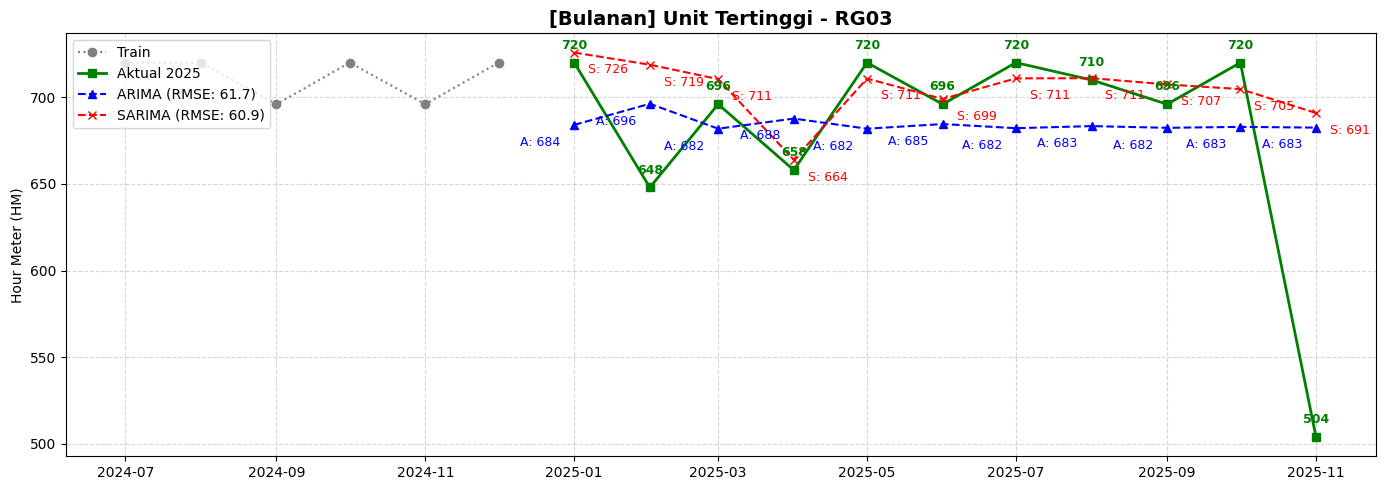

Rincian Tabel Prediksi Bulanan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2025-01-01,720.0,684.1,725.8
2025-02-01,648.0,696.3,718.8
2025-03-01,696.0,681.9,710.5
2025-04-01,658.0,687.7,664.0
2025-05-01,720.0,681.9,710.8
2025-06-01,696.0,684.6,699.0
2025-07-01,720.0,682.2,710.9
2025-08-01,710.0,683.4,711.0
2025-09-01,696.0,682.4,707.4
2025-10-01,720.0,682.9,704.7




[Bulanan] Memproses Unit Tertinggi: RG02


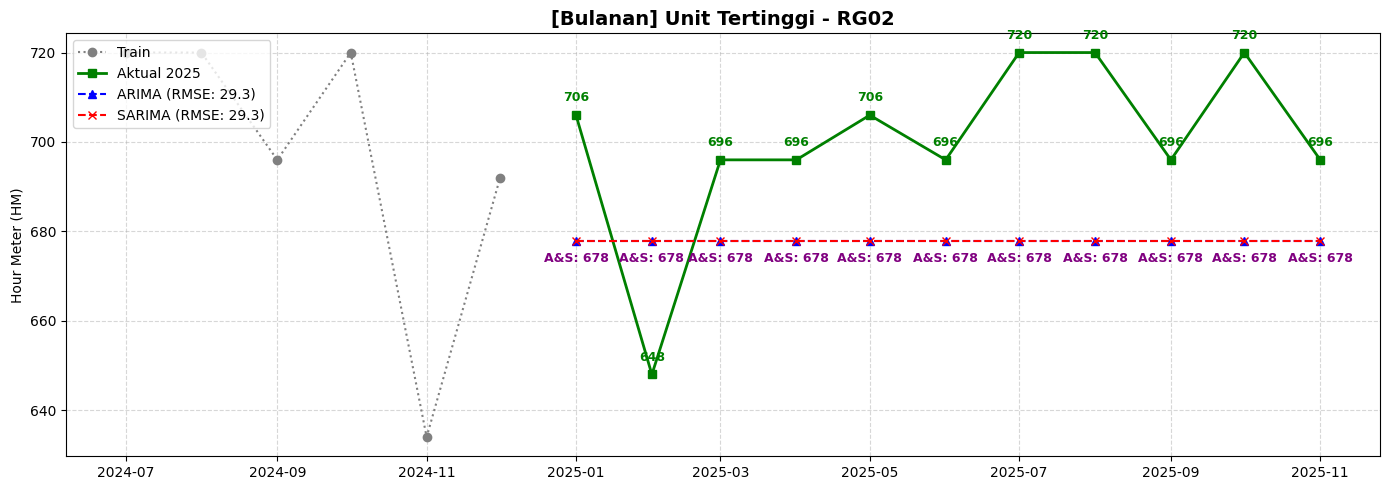

Rincian Tabel Prediksi Bulanan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2025-01-01,706.0,677.8,677.8
2025-02-01,648.0,677.8,677.8
2025-03-01,696.0,677.8,677.8
2025-04-01,696.0,677.8,677.8
2025-05-01,706.0,677.8,677.8
2025-06-01,696.0,677.8,677.8
2025-07-01,720.0,677.8,677.8
2025-08-01,720.0,677.8,677.8
2025-09-01,696.0,677.8,677.8
2025-10-01,720.0,677.8,677.8




[Bulanan] Memproses Unit Tertinggi: RG01


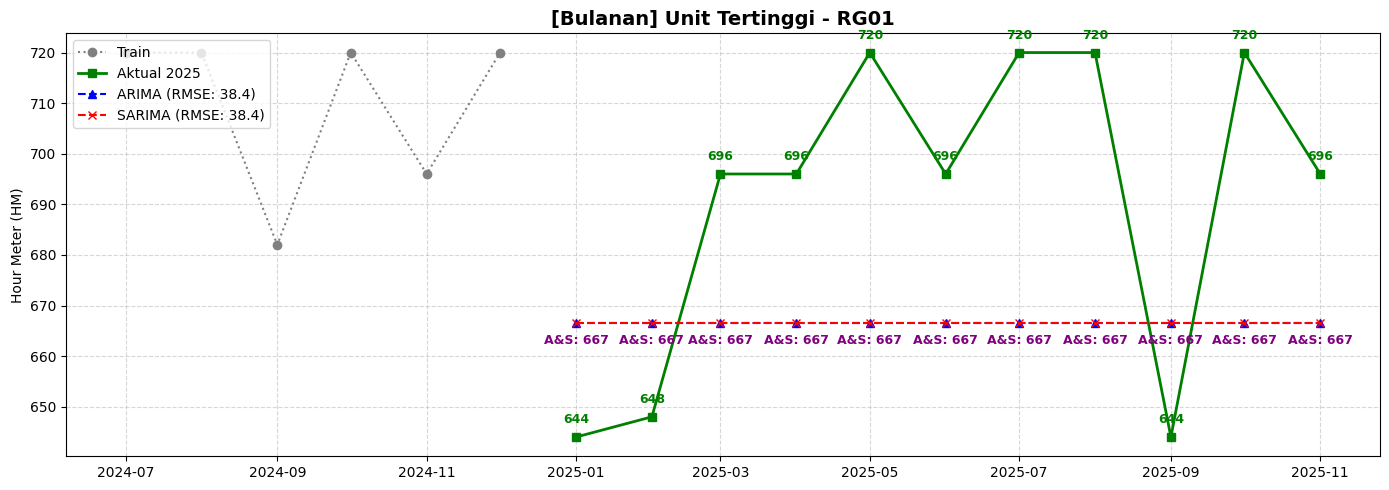

Rincian Tabel Prediksi Bulanan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2025-01-01,644.0,666.6,666.6
2025-02-01,648.0,666.6,666.6
2025-03-01,696.0,666.6,666.6
2025-04-01,696.0,666.6,666.6
2025-05-01,720.0,666.6,666.6
2025-06-01,696.0,666.6,666.6
2025-07-01,720.0,666.6,666.6
2025-08-01,720.0,666.6,666.6
2025-09-01,644.0,666.6,666.6
2025-10-01,720.0,666.6,666.6




[Bulanan] Memproses Unit Terendah: LANDAK


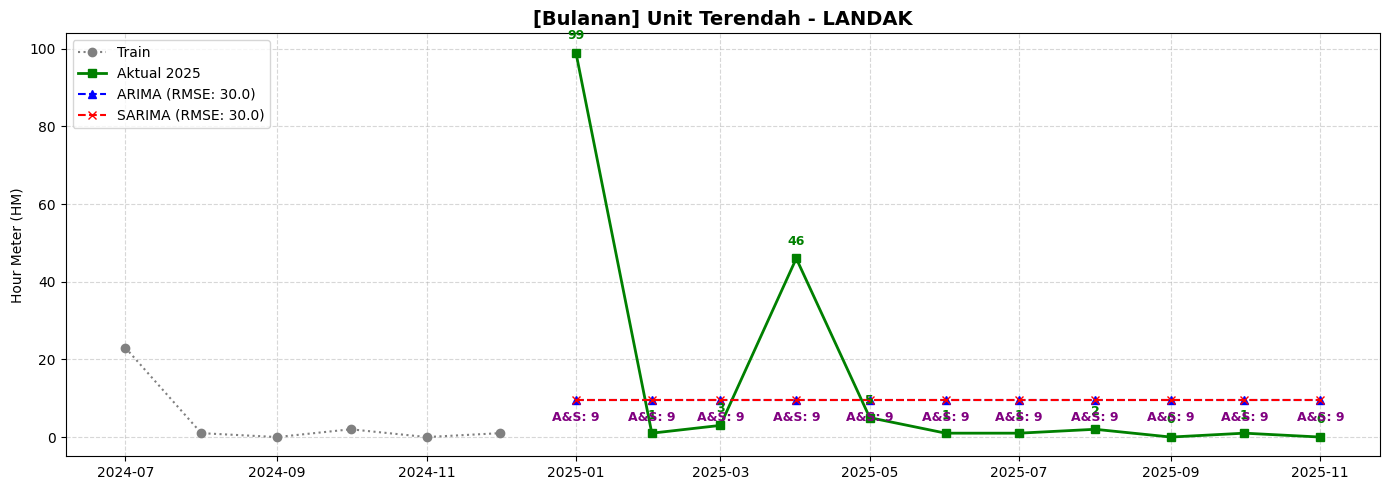

Rincian Tabel Prediksi Bulanan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2025-01-01,99.0,9.5,9.5
2025-02-01,1.0,9.5,9.5
2025-03-01,3.0,9.5,9.5
2025-04-01,46.0,9.5,9.5
2025-05-01,5.0,9.5,9.5
2025-06-01,1.0,9.5,9.5
2025-07-01,1.0,9.5,9.5
2025-08-01,2.0,9.5,9.5
2025-09-01,0.0,9.5,9.5
2025-10-01,1.0,9.5,9.5




[Bulanan] Memproses Unit Terendah: L 8085 SK ( EX L 7287 TF )


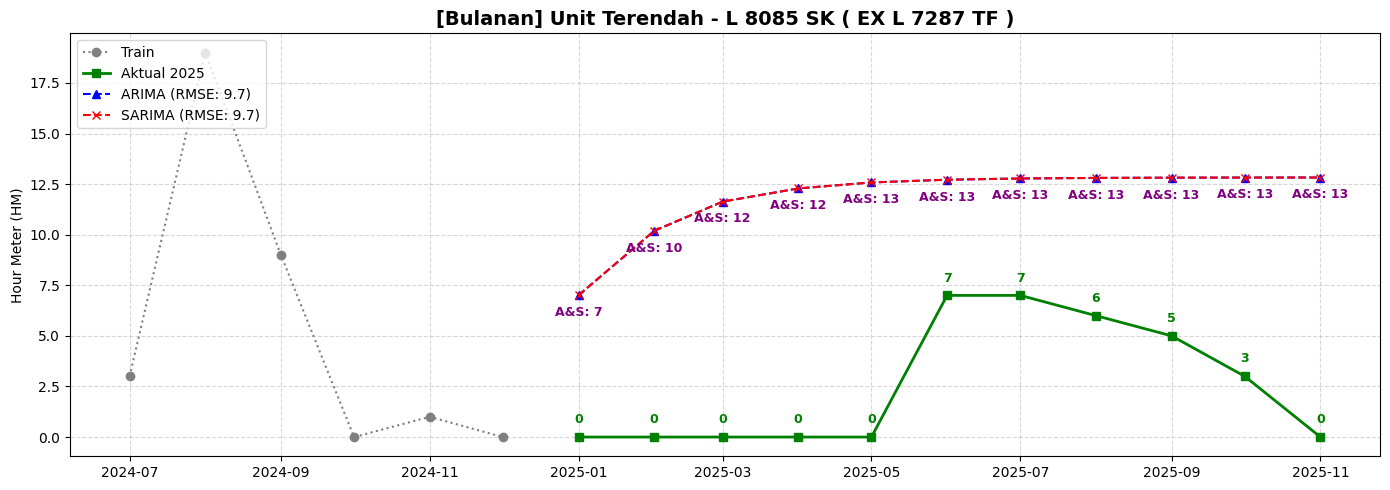

Rincian Tabel Prediksi Bulanan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2025-01-01,0.0,7.0,7.0
2025-02-01,0.0,10.2,10.2
2025-03-01,0.0,11.6,11.6
2025-04-01,0.0,12.3,12.3
2025-05-01,0.0,12.6,12.6
2025-06-01,7.0,12.7,12.7
2025-07-01,7.0,12.8,12.8
2025-08-01,6.0,12.8,12.8
2025-09-01,5.0,12.8,12.8
2025-10-01,3.0,12.8,12.8




[Bulanan] Memproses Unit Terendah: SOKA


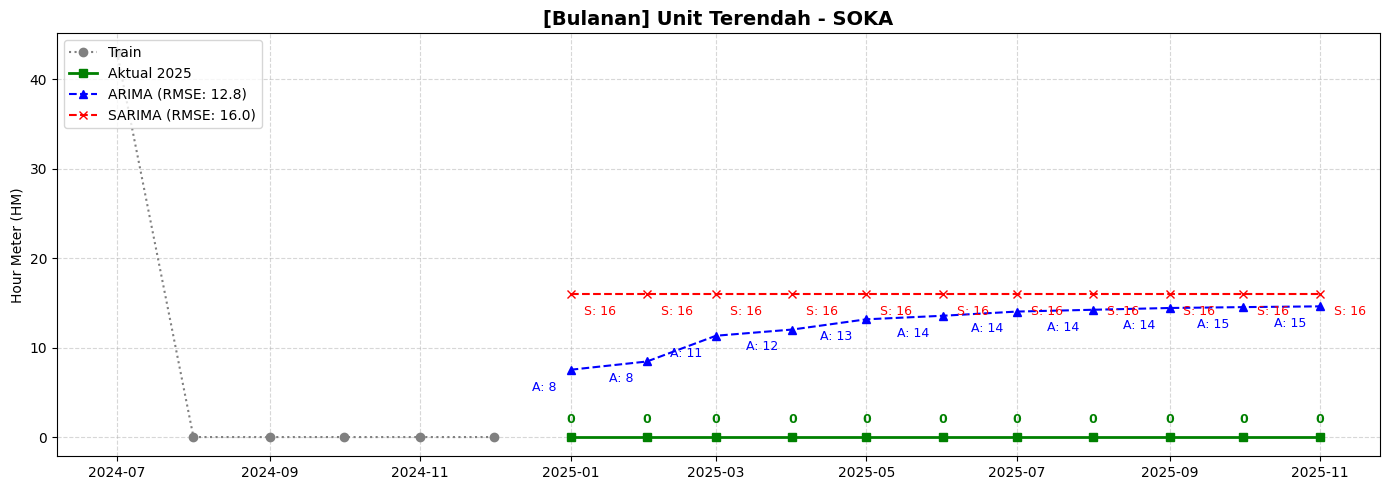

Rincian Tabel Prediksi Bulanan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2025-01-01,0.0,7.5,16.0
2025-02-01,0.0,8.5,16.0
2025-03-01,0.0,11.3,16.0
2025-04-01,0.0,12.0,16.0
2025-05-01,0.0,13.2,16.0
2025-06-01,0.0,13.6,16.0
2025-07-01,0.0,14.0,16.0
2025-08-01,0.0,14.2,16.0
2025-09-01,0.0,14.4,16.0
2025-10-01,0.0,14.5,16.0




[Bulanan] Memproses Jenis Rata-rata Tertinggi: CRANE


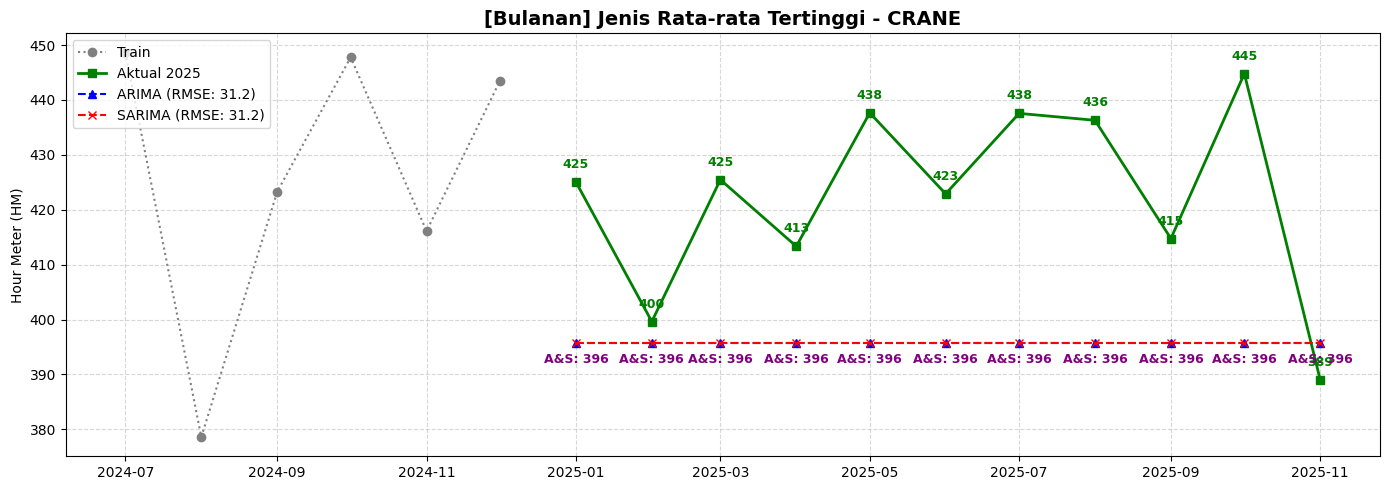

Rincian Tabel Prediksi Bulanan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2025-01-01,425.1,395.8,395.8
2025-02-01,399.6,395.8,395.8
2025-03-01,425.5,395.8,395.8
2025-04-01,413.3,395.8,395.8
2025-05-01,437.7,395.8,395.8
2025-06-01,422.9,395.8,395.8
2025-07-01,437.6,395.8,395.8
2025-08-01,436.3,395.8,395.8
2025-09-01,414.8,395.8,395.8
2025-10-01,444.8,395.8,395.8




[Bulanan] Memproses Jenis Rata-rata Terendah: TOP LOADER


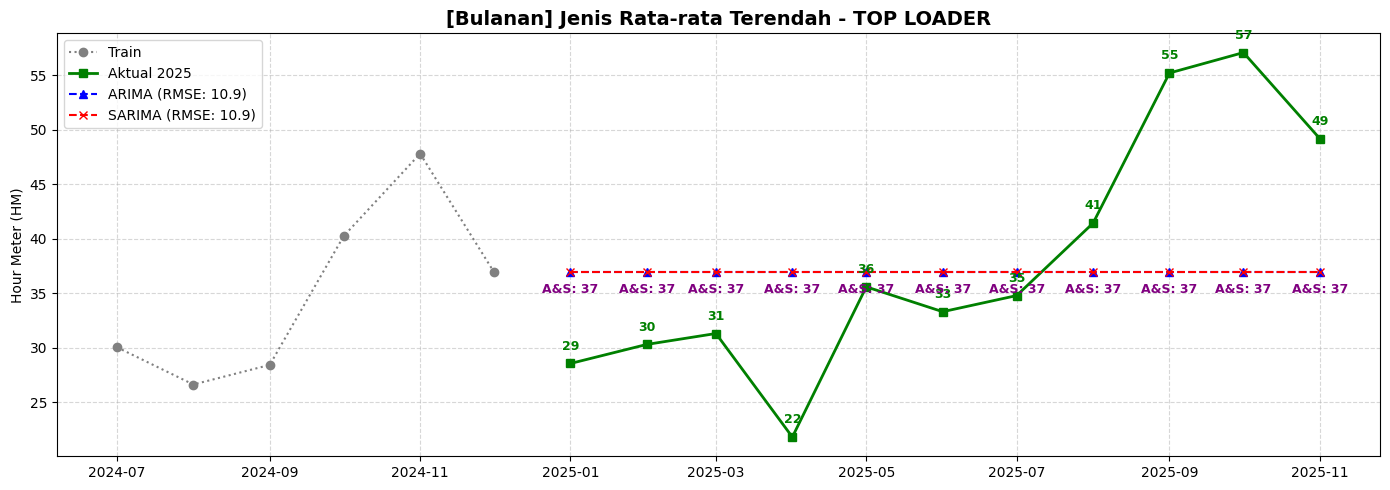

Rincian Tabel Prediksi Bulanan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2025-01-01,28.5,36.9,36.9
2025-02-01,30.3,36.9,36.9
2025-03-01,31.3,36.9,36.9
2025-04-01,21.8,36.9,36.9
2025-05-01,35.6,36.9,36.9
2025-06-01,33.3,36.9,36.9
2025-07-01,34.8,36.9,36.9
2025-08-01,41.4,36.9,36.9
2025-09-01,55.2,36.9,36.9
2025-10-01,57.1,36.9,36.9





DATA MINGGUAN (m=52)
[Mingguan] Memproses Unit Tertinggi: RG03


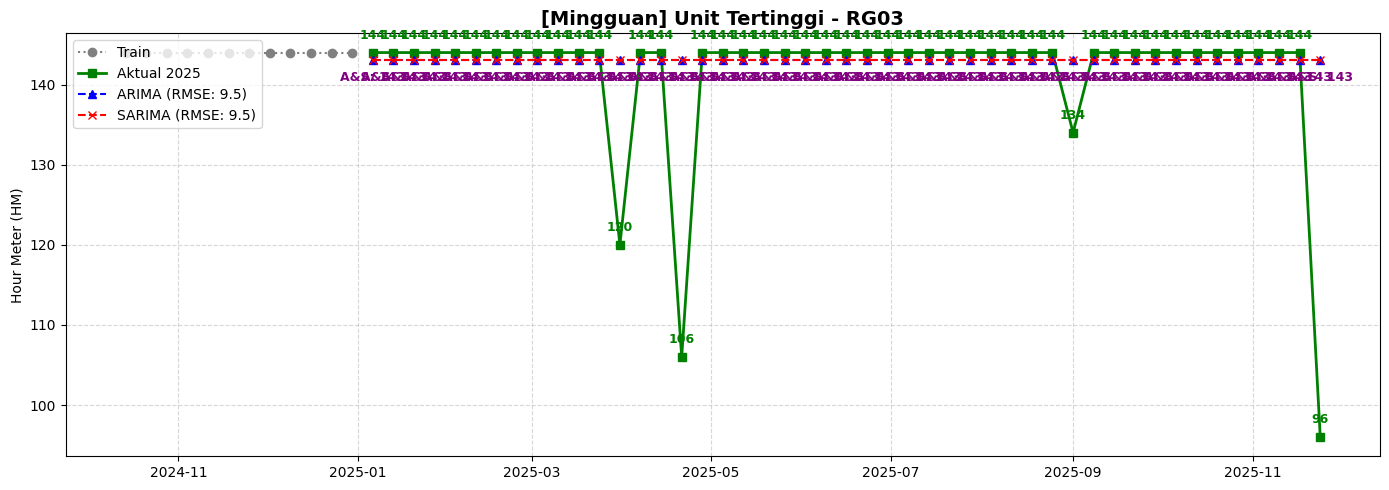

Rincian Tabel Prediksi Mingguan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2025-01-06,144.0,143.1,143.1
2025-01-13,144.0,143.1,143.1
2025-01-20,144.0,143.1,143.1
2025-01-27,144.0,143.1,143.1
2025-02-03,144.0,143.1,143.1
2025-02-10,144.0,143.1,143.1
2025-02-17,144.0,143.1,143.1
2025-02-24,144.0,143.1,143.1
2025-03-03,144.0,143.1,143.1
2025-03-10,144.0,143.1,143.1




[Mingguan] Memproses Unit Tertinggi: RG02


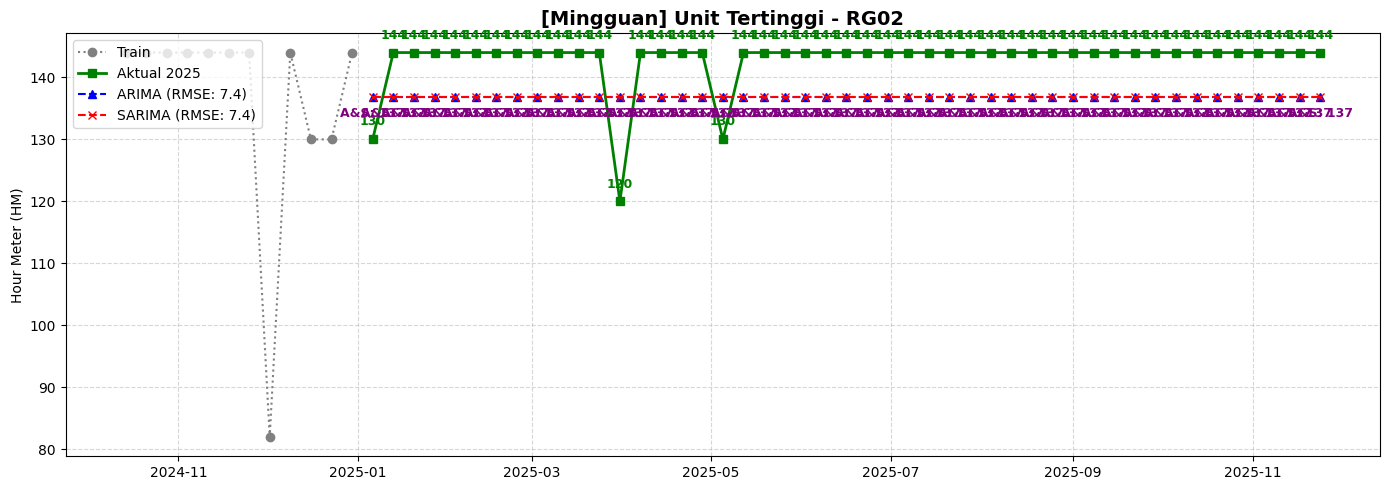

Rincian Tabel Prediksi Mingguan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2025-01-06,130.0,136.9,136.9
2025-01-13,144.0,136.9,136.9
2025-01-20,144.0,136.9,136.9
2025-01-27,144.0,136.9,136.9
2025-02-03,144.0,136.9,136.9
2025-02-10,144.0,136.9,136.9
2025-02-17,144.0,136.9,136.9
2025-02-24,144.0,136.9,136.9
2025-03-03,144.0,136.9,136.9
2025-03-10,144.0,136.9,136.9




[Mingguan] Memproses Unit Tertinggi: RG01


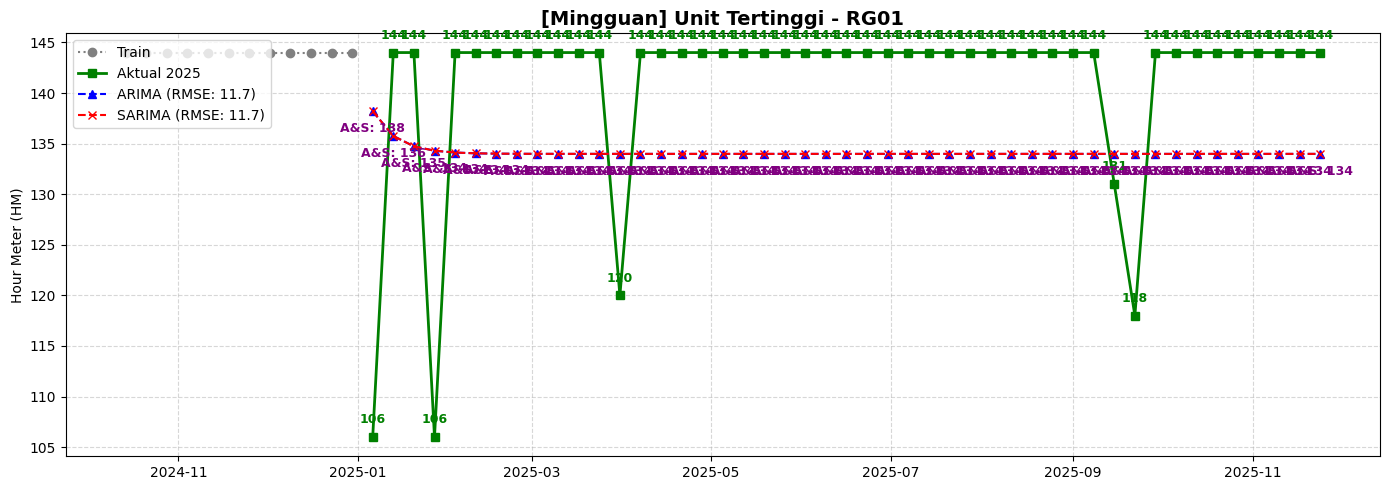

Rincian Tabel Prediksi Mingguan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2025-01-06,106.0,138.2,138.2
2025-01-13,144.0,135.8,135.8
2025-01-20,144.0,134.7,134.7
2025-01-27,106.0,134.3,134.3
2025-02-03,144.0,134.1,134.1
2025-02-10,144.0,134.0,134.0
2025-02-17,144.0,134.0,134.0
2025-02-24,144.0,134.0,134.0
2025-03-03,144.0,134.0,134.0
2025-03-10,144.0,134.0,134.0




[Mingguan] Memproses Unit Terendah: LANDAK


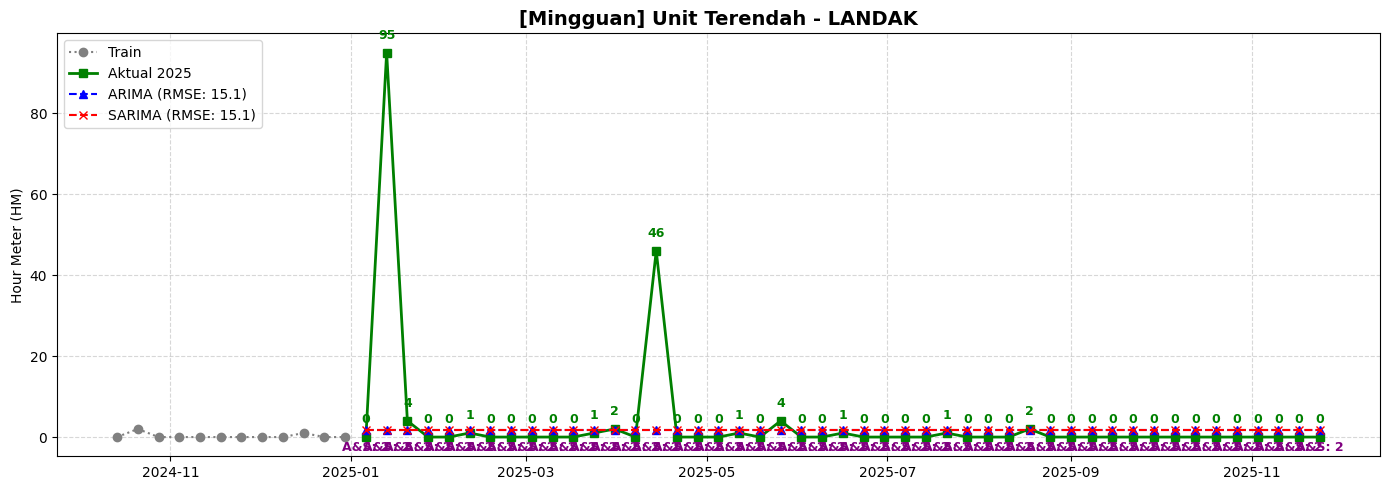

Rincian Tabel Prediksi Mingguan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2025-01-06,0.0,1.8,1.8
2025-01-13,95.0,1.8,1.8
2025-01-20,4.0,1.8,1.8
2025-01-27,0.0,1.8,1.8
2025-02-03,0.0,1.8,1.8
2025-02-10,1.0,1.8,1.8
2025-02-17,0.0,1.8,1.8
2025-02-24,0.0,1.8,1.8
2025-03-03,0.0,1.8,1.8
2025-03-10,0.0,1.8,1.8




[Mingguan] Memproses Unit Terendah: L 8085 SK ( EX L 7287 TF )


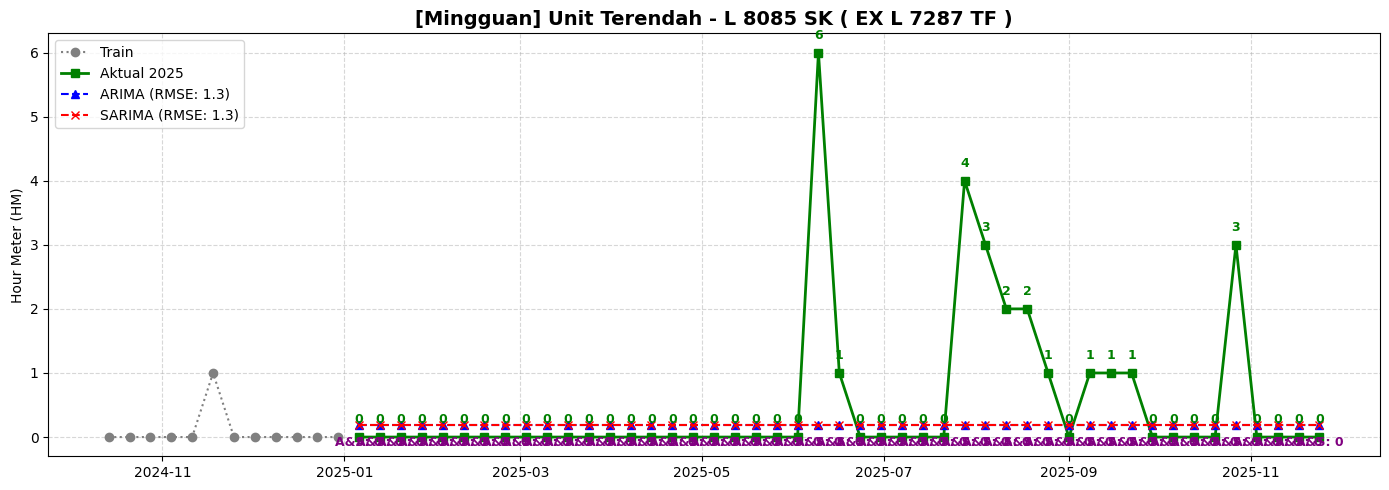

Rincian Tabel Prediksi Mingguan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2025-01-06,0.0,0.2,0.2
2025-01-13,0.0,0.2,0.2
2025-01-20,0.0,0.2,0.2
2025-01-27,0.0,0.2,0.2
2025-02-03,0.0,0.2,0.2
2025-02-10,0.0,0.2,0.2
2025-02-17,0.0,0.2,0.2
2025-02-24,0.0,0.2,0.2
2025-03-03,0.0,0.2,0.2
2025-03-10,0.0,0.2,0.2




[Mingguan] Memproses Unit Terendah: SOKA


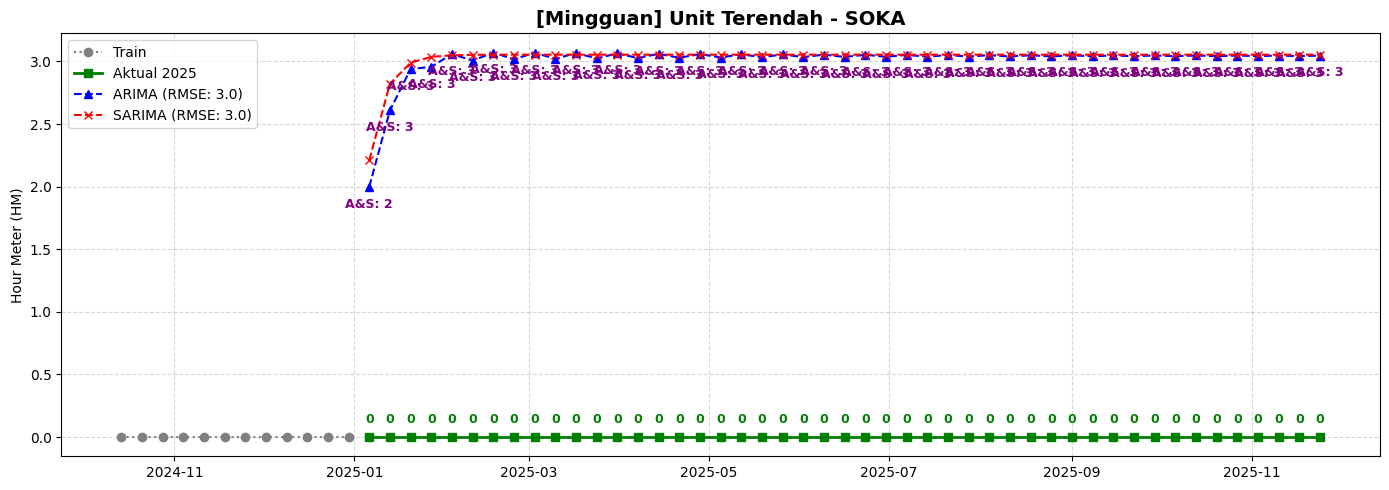

Rincian Tabel Prediksi Mingguan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2025-01-06,0.0,2.0,2.2
2025-01-13,0.0,2.6,2.8
2025-01-20,0.0,2.9,3.0
2025-01-27,0.0,3.0,3.0
2025-02-03,0.0,3.1,3.0
2025-02-10,0.0,3.0,3.1
2025-02-17,0.0,3.1,3.1
2025-02-24,0.0,3.0,3.1
2025-03-03,0.0,3.1,3.1
2025-03-10,0.0,3.0,3.1




[Mingguan] Memproses Jenis Rata-rata Tertinggi: CRANE


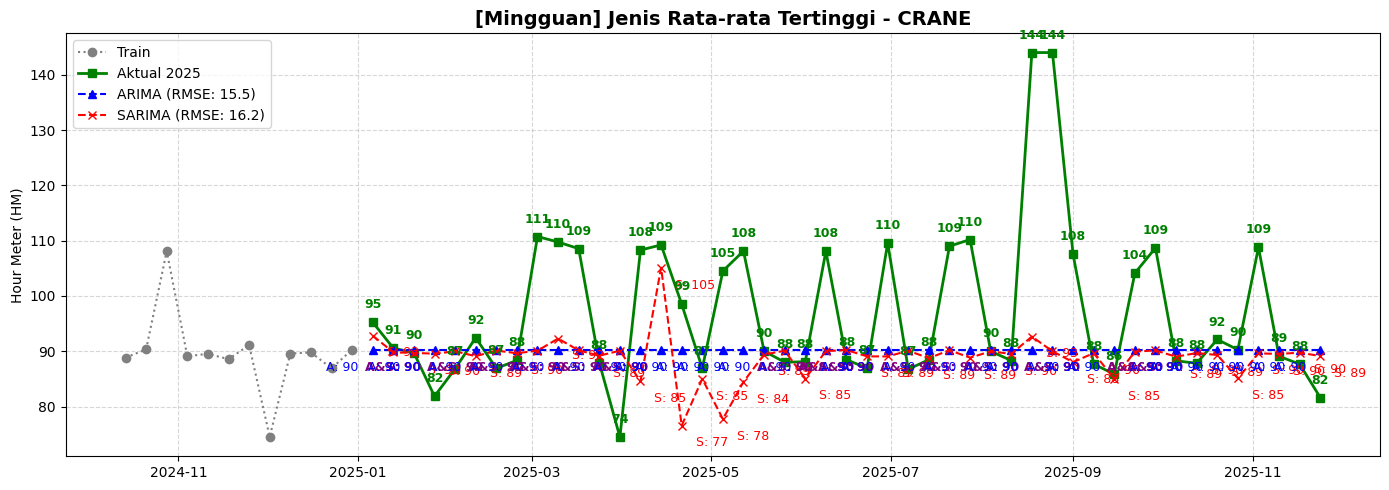

Rincian Tabel Prediksi Mingguan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2025-01-06,95.2,90.3,92.8
2025-01-13,90.6,90.3,89.8
2025-01-20,89.7,90.3,89.7
2025-01-27,81.9,90.3,89.6
2025-02-03,86.8,90.3,90.0
2025-02-10,92.5,90.3,89.1
2025-02-17,86.9,90.3,90.1
2025-02-24,88.4,90.3,89.7
2025-03-03,110.8,90.3,90.1
2025-03-10,109.8,90.3,92.3




[Mingguan] Memproses Jenis Rata-rata Terendah: TOP LOADER


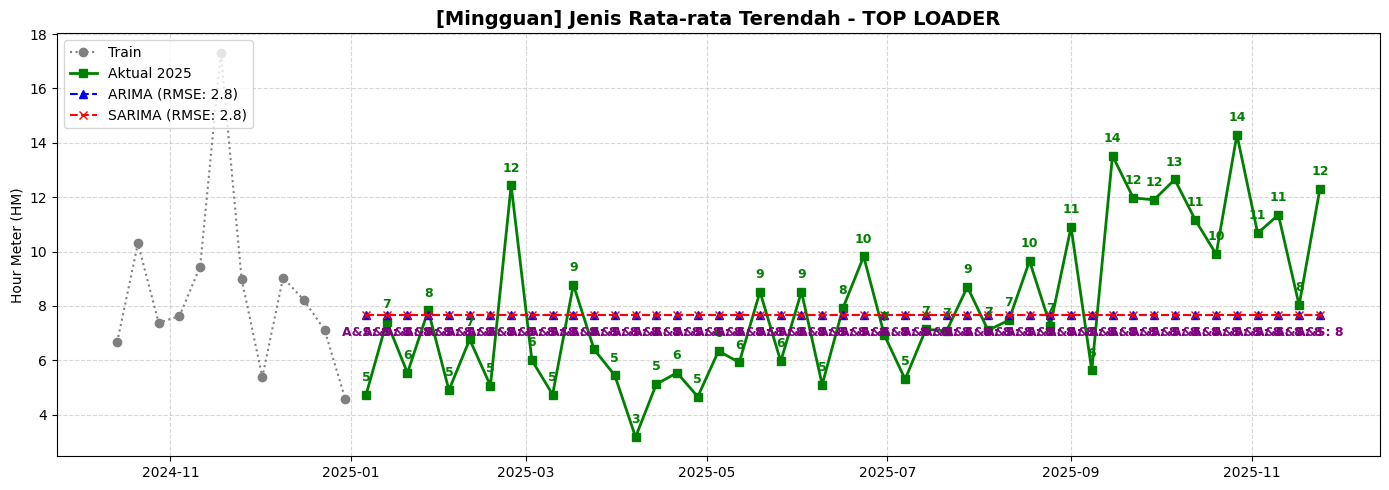

Rincian Tabel Prediksi Mingguan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2025-01-06,4.7,7.7,7.7
2025-01-13,7.4,7.7,7.7
2025-01-20,5.5,7.7,7.7
2025-01-27,7.8,7.7,7.7
2025-02-03,4.9,7.7,7.7
2025-02-10,6.8,7.7,7.7
2025-02-17,5.1,7.7,7.7
2025-02-24,12.4,7.7,7.7
2025-03-03,6.0,7.7,7.7
2025-03-10,4.7,7.7,7.7


In [21]:
hasil_eksperimen = []

print("DATA BULANAN (m=12)")

# 1. Eksekusi Unit (Bulanan)
for unit in top_3_units:
    res = run_arima_vs_sarima(unit, is_type=False, freq='M', kategori_target="Unit Tertinggi")
    hasil_eksperimen.append(res)

for unit in bottom_3_units:
    res = run_arima_vs_sarima(unit, is_type=False, freq='M', kategori_target="Unit Terendah")
    hasil_eksperimen.append(res)

# 2. Eksekusi Jenis (Bulanan)
res = run_arima_vs_sarima(top_1_type, is_type=True, freq='M', kategori_target="Jenis Rata-rata Tertinggi")
hasil_eksperimen.append(res)

res = run_arima_vs_sarima(bottom_1_type, is_type=True, freq='M', kategori_target="Jenis Rata-rata Terendah")
hasil_eksperimen.append(res)


print("\nDATA MINGGUAN (m=52)")

# 3. Eksekusi Unit (Mingguan)
for unit in top_3_units:
    res = run_arima_vs_sarima(unit, is_type=False, freq='W', kategori_target="Unit Tertinggi")
    hasil_eksperimen.append(res)

for unit in bottom_3_units:
    res = run_arima_vs_sarima(unit, is_type=False, freq='W', kategori_target="Unit Terendah")
    hasil_eksperimen.append(res)

# 4. Eksekusi Jenis (Mingguan)
res = run_arima_vs_sarima(top_1_type, is_type=True, freq='W', kategori_target="Jenis Rata-rata Tertinggi")
hasil_eksperimen.append(res)

res = run_arima_vs_sarima(bottom_1_type, is_type=True, freq='W', kategori_target="Jenis Rata-rata Terendah")
hasil_eksperimen.append(res)

In [22]:
df_hasil = pd.DataFrame(hasil_eksperimen)

df_hasil['Rel_RMSE_ARIMA (%)'] = np.where(df_hasil['Rata_Aktual_2025'] > 0, 
                                          (df_hasil['RMSE_ARIMA'] / df_hasil['Rata_Aktual_2025']) * 100, 0)
df_hasil['Rel_RMSE_SARIMA (%)'] = np.where(df_hasil['Rata_Aktual_2025'] > 0, 
                                           (df_hasil['RMSE_SARIMA'] / df_hasil['Rata_Aktual_2025']) * 100, 0)

def tentukan_pemenang(row):
    if pd.isna(row['RMSE_SARIMA']): return "ARIMA"
    return "SARIMA" if row['RMSE_SARIMA'] < row['RMSE_ARIMA'] else "ARIMA"

df_hasil['Model_Terbaik'] = df_hasil.apply(tentukan_pemenang, axis=1)

print("\nTABEL KESIMPULAN")
cols = ['Kategori', 'Target', 'Frekuensi', 'Rata_Aktual_2025', 'RMSE_ARIMA', 'Rel_RMSE_ARIMA (%)', 'RMSE_SARIMA', 'Rel_RMSE_SARIMA (%)', 'Model_Terbaik']
display(df_hasil[cols].round(2))


TABEL KESIMPULAN


,Kategori,Target,Frekuensi,Rata_Aktual_2025,RMSE_ARIMA,Rel_RMSE_ARIMA (%),RMSE_SARIMA,Rel_RMSE_SARIMA (%),Model_Terbaik
0,Unit Tertinggi,RG03,Bulanan,680.73,61.68,9.06,60.89,8.94,SARIMA
1,Unit Tertinggi,RG02,Bulanan,700.00,29.33,4.19,29.33,4.19,ARIMA
2,Unit Tertinggi,RG01,Bulanan,690.91,38.42,5.56,38.42,5.56,ARIMA
3,Unit Terendah,LANDAK,Bulanan,14.45,30.05,207.89,30.05,207.89,ARIMA
4,Unit Terendah,L 8085 SK ( EX L 7287 TF ),Bulanan,2.55,9.69,380.52,9.69,380.52,ARIMA
5,Unit Terendah,SOKA,Bulanan,0.00,12.76,0.00,16.00,0.00,ARIMA
6,Jenis Rata-rata Tertinggi,CRANE,Bulanan,422.41,31.24,7.40,31.24,7.40,ARIMA
7,Jenis Rata-rata Terendah,TOP LOADER,Bulanan,38.04,10.89,28.62,10.89,28.62,ARIMA
8,Unit Tertinggi,RG03,Mingguan,141.45,9.50,6.72,9.50,6.72,ARIMA
9,Unit Tertinggi,RG02,Mingguan,142.89,7.44,5.21,7.44,5.21,ARIMA


# Per Unit

In [26]:
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.express as px
import pandas as pd

def plot_unit_dispersion_stacked(jenis_target):
    fig = go.Figure()
    
    unit_dalam_jenis = df_train[df_train['TYPE'] == jenis_target]['EQUIP NAME'].unique()
    
    if len(unit_dalam_jenis) == 0:
        print(f"Tidak ada unit yang aktif untuk jenis {jenis_target}.")
        return

    colors = px.colors.qualitative.Alphabet * 5

    # Konfigurasi tampilan per tahun
    tahun_config = {
        2023: {'dash': 'dot',    'symbol': 'diamond', 'label': '2023'},
        2024: {'dash': 'solid',  'symbol': 'circle',  'label': '2024'},
        2025: {'dash': 'dash',   'symbol': 'square',  'label': '2025'},
    }

    for idx, unit_nama in enumerate(unit_dalam_jenis):
        train, test = prep_timeseries(unit_nama, is_type=False, freq='M')

        # Gabungkan train dan test untuk dapat data 2025 juga
        ts_full = pd.concat([train, test])
        
        # --- PERBAIKAN: Pastikan index berbentuk Datetime dengan Aman ---
        # Cek apakah ts_full berupa DataFrame sebelum memanggil .columns
        if isinstance(ts_full, pd.DataFrame):
            if 'TANGGAL' in ts_full.columns:
                ts_full['TANGGAL'] = pd.to_datetime(ts_full['TANGGAL'])
                ts_full = ts_full.set_index('TANGGAL')
            elif 'Tanggal' in ts_full.columns:
                ts_full['Tanggal'] = pd.to_datetime(ts_full['Tanggal'])
                ts_full = ts_full.set_index('Tanggal')
                
        # Jika index belum berbentuk Datetime (baik itu Series maupun DataFrame), paksa ubah
        if not isinstance(ts_full.index, pd.DatetimeIndex):
            try:
                ts_full.index = pd.to_datetime(ts_full.index)
            except:
                pass 
        # ---------------------------------------------------

        # Ambil nilai HM_Value dengan aman
        if isinstance(ts_full, pd.DataFrame):
            if 'HM_Value' in ts_full.columns:
                df_temp = ts_full[['HM_Value']].copy()
            else:
                df_temp = pd.DataFrame({'HM_Value': ts_full.iloc[:, 0]})
        else:
            # Jika ts_full adalah Series, langsung konversi menjadi DataFrame
            df_temp = pd.DataFrame({'HM_Value': ts_full})
            
        df_temp['Tahun'] = df_temp.index.year
        df_temp['Bulan'] = df_temp.index.month
        df_temp = df_temp[df_temp['Tahun'].isin([2023, 2024, 2025])]
        pivot = df_temp.pivot(index='Bulan', columns='Tahun', values='HM_Value')

        bulan_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun',
                        'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']

        for tahun, cfg in tahun_config.items():
            if tahun not in pivot.columns:
                continue
            data_tahun = pivot[tahun]
            if not data_tahun.notna().any():
                continue

            # Untuk 2025 hanya Jan-Nov, bulan sisanya jadi None agar garis tidak nyambung ke 0
            if tahun == 2025:
                data_tahun = data_tahun.reindex(range(1, 13))
                data_tahun.iloc[11] = None  # Des 2025 tidak ada datanya

            fig.add_trace(go.Scatter(
                x=bulan_labels,
                y=data_tahun.values,
                mode='lines+markers',
                name=f"{unit_nama} ({cfg['label']})",
                legendgroup=unit_nama,
                legendgrouptitle_text=unit_nama if tahun == 2023 else None,
                line=dict(color=colors[idx], width=2, dash=cfg['dash']),
                marker=dict(size=5, symbol=cfg['symbol']),
                opacity=0.8,
                connectgaps=False,
                hovertemplate=(
                    f"<b>{unit_nama} ({cfg['label']})</b><br>"
                    "Bulan: %{x}<br>HM: %{y:.1f}<extra></extra>"
                )
            ))

    fig.update_layout(
        title=(
            f"<b>Sebaran Beban Kerja (Tumpukan Jan–Des)<br>"
            f"Kategori: {jenis_target}</b><br>"
            f"<span style='font-size:11px;'>"
            f"Titik-titik: 2023 &nbsp;|&nbsp; Garis Solid: 2024 &nbsp;|&nbsp; Putus-putus: 2025 (Jan–Nov)"
            f"</span>"
        ),
        xaxis_title='Bulan',
        yaxis_title='Hour Meter (HM)',
        template='plotly_white',
        hovermode='closest',
        legend=dict(
            title="Unit & Tahun:",
            groupclick="toggleitem",
            orientation="v",
            yanchor="top",
            y=1,
            xanchor="left",
            x=1.02,
            font=dict(size=10)
        ),
        margin=dict(l=40, r=270, t=100, b=40)
    )

    fig.show()

# ===================================================================
# UI BUILDER (WIDGET DROPDOWN)
# ===================================================================
list_jenis_valid = sorted([t for t in df_train['TYPE'].unique() if t != 'TIDAK TERDAFTAR'])

dropdown_jenis = widgets.Dropdown(
    options=list_jenis_valid,
    value=list_jenis_valid[0],
    description='Pilih Jenis:',
    disabled=False,
    layout={'width': '400px'}
)

output_plot_dispersi = widgets.Output()

def on_jenis_change(change):
    pilihan_jenis = change['new']
    with output_plot_dispersi:
        clear_output(wait=True)
        plot_unit_dispersion_stacked(pilihan_jenis)

dropdown_jenis.observe(on_jenis_change, names='value')

print("=== DASHBOARD SEBARAN UNIT (TUMPUKAN 12 BULAN) ===")
display(dropdown_jenis)
display(output_plot_dispersi)

with output_plot_dispersi:
    plot_unit_dispersion_stacked(dropdown_jenis.value)

=== DASHBOARD SEBARAN UNIT (TUMPUKAN 12 BULAN) ===


Dropdown(description='Pilih Jenis:', layout=Layout(width='400px'), options=('CRANE', 'FORKLIFT', 'REACH STACKE…

Output()